# Laboratorio #1 — Entrenamiento de Redes Neuronales (MLP)
### CC3092 - Deep Learning y Sistemas Inteligentes

**Repositorio:** _(agregar enlace antes de entregar)_

Este notebook implementa un Perceptrón Multicapa (MLP) de regresión sobre el dataset
**California Housing Prices**, siguiendo las secciones del enunciado:

1. Dataset
2. Exploración y preparación de los datos
3. Investigación: capas y optimizadores de PyTorch
4. Entrenamiento e iteración de hiperparámetros (10+ iteraciones)
5. Documentación de resultados
6. Discusión y análisis


## 0. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Dataset

Se usa el dataset público **California Housing Prices** (fuente Kaggle:
[camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)).
El archivo `housing.csv` se descargó del mirror canónico del propio autor del dataset
(repositorio *Hands-On Machine Learning*, Aurélien Géron) y coincide fila por fila y
columna por columna con la versión de Kaggle.

Problema: **regresión**. Se predice `median_house_value` (valor mediano de vivienda en
USD) a partir de características socioeconómicas y geográficas de distritos censales
de California (censo de 1990).

In [2]:
df = pd.read_csv("data/housing.csv")
df.shape

(20640, 10)

## 2. Exploración y preparación de los datos

### ¿Cuántas observaciones y cuántas variables tiene el dataset?

20,640 observaciones (distritos censales) y 10 variables (9 features + 1 target).

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### ¿Qué representa cada variable y cuál es el target?

| Variable | Significado |
|---|---|
| `longitude` / `latitude` | Coordenadas geográficas del distrito |
| `housing_median_age` | Edad mediana de las viviendas del distrito (años) |
| `total_rooms` | Total de cuartos en el distrito |
| `total_bedrooms` | Total de dormitorios en el distrito |
| `population` | Población del distrito |
| `households` | Número de hogares del distrito |
| `median_income` | Ingreso mediano de los hogares (en decenas de miles de USD) |
| `ocean_proximity` | Categoría de cercanía al océano (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`) |
| **`median_house_value`** | **Target**: valor mediano de vivienda del distrito (USD) |

### ¿Hay valores nulos, duplicados o atípicos?

In [4]:
print("Nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFilas duplicadas:", df.duplicated().sum())
df["median_house_value"].describe()

Nulos por columna:
total_bedrooms    207
dtype: int64

Filas duplicadas: 0


count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

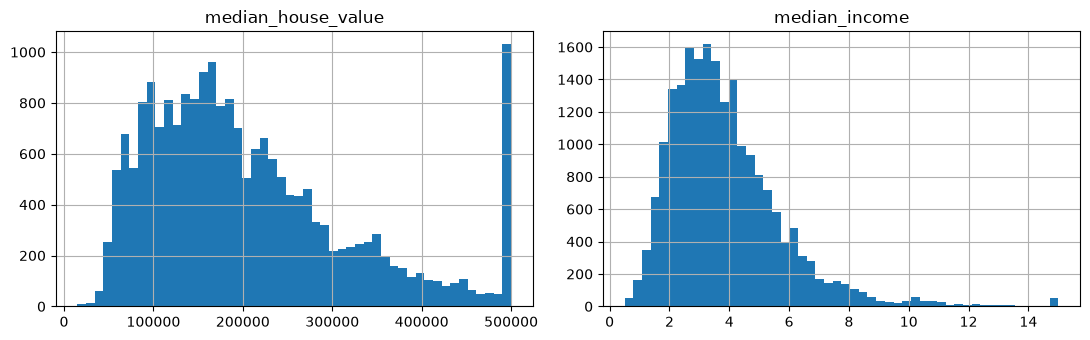

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df["median_house_value"].hist(bins=50, ax=axes[0])
axes[0].set_title("median_house_value")
df["median_income"].hist(bins=50, ax=axes[1])
axes[1].set_title("median_income")
plt.tight_layout()
plt.show()

**Hallazgos:**
- `total_bedrooms` tiene **207 valores nulos** (~1% de las filas). Se imputan más
  adelante con la **mediana calculada solo sobre el conjunto de entrenamiento**
  (para no filtrar información de val/test).
- **No hay filas duplicadas.**
- `median_house_value` está **truncado (capped) en 500,001 USD**: se observa un pico
  artificial en el histograma en ese valor — es un límite de captura del censo de 1990,
  no un outlier real. Se deja así (no se elimina ni recorta) porque afecta a un
  porcentaje pequeño de filas y removerlas reduciría el dataset sin evidencia de que
  sean errores; se documenta como limitación conocida del dataset.
- `median_income` y `total_rooms`/`population`/`households` tienen colas largas hacia
  la derecha (distritos con ingresos o tamaños muy altos) — es una asimetría propia del
  dominio (ingresos y tamaños de población siguen distribuciones sesgadas), no errores
  de captura, así que no se eliminan como outliers.

### ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo se codificó la categórica?

Todas son numéricas excepto `ocean_proximity` (categórica nominal, 5 categorías). Se
codifica con **one-hot encoding** (`pd.get_dummies`), apropiado porque no existe un
orden natural entre las categorías (a diferencia de una codificación ordinal).

In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### ¿Fue necesario normalizar/escalar las variables numéricas?

Sí. Las features numéricas tienen escalas muy distintas (`median_income` ~0-15 vs
`total_rooms` ~2-40,000), y un MLP entrena con **descenso de gradiente**: si las
escalas difieren en órdenes de magnitud, el gradiente está dominado por las features de
mayor escala y la optimización converge más lento o de forma inestable. Se aplica
`StandardScaler` (media 0, desviación estándar 1), **ajustado solo con el conjunto de
entrenamiento** y aplicado luego a validación y test, para evitar fuga de información.

### Limpieza, encoding y split train/val/test

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# One-hot encoding de la variable categórica
df_enc = pd.get_dummies(df, columns=["ocean_proximity"], prefix="ocean")

X = df_enc.drop(columns=["median_house_value"])
y = df_enc["median_house_value"].values.astype("float32")

feature_names = X.columns.tolist()
X = X.values.astype("float32")

# Split 60/20/20 -- train / val / test. El test se aparta primero y no se vuelve
# a tocar hasta la evaluacion final (Seccion 6).
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

train: (12384, 13), val: (4128, 13), test: (4128, 13)


In [8]:
# Imputacion de nulos (total_bedrooms): mediana calculada SOLO con train
bedrooms_idx = feature_names.index("total_bedrooms")
imputer = SimpleImputer(strategy="median")
X_train[:, [bedrooms_idx]] = imputer.fit_transform(X_train[:, [bedrooms_idx]])
X_val[:, [bedrooms_idx]] = imputer.transform(X_val[:, [bedrooms_idx]])
X_test[:, [bedrooms_idx]] = imputer.transform(X_test[:, [bedrooms_idx]])

# Escalado: ajustado SOLO con train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

assert not np.isnan(X_train).any() and not np.isnan(X_val).any() and not np.isnan(X_test).any()
assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == len(df)
print("Sin nulos. Split completo:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

Sin nulos. Split completo: 12384 4128 4128


**Regla de aislamiento del test respetada:** el imputer y el scaler se ajustan
(`fit`) únicamente sobre `X_train`; a validación y test solo se les aplica `transform`.
Así ninguna estadística de val/test (mediana, media, desviación) influye en el
preprocesamiento, y el conjunto de test queda intacto para la evaluación final.

## 3. Investigación: capas y optimizadores de PyTorch

_(Batch 2)_

## 4. Definición del modelo y entrenamiento

_(Batch 3)_

## 5. Iteración de hiperparámetros (10+ configuraciones)

_(Batch 4)_

## 6. Evaluación final sobre test

_(Batch 5)_

## 7. Documentación de resultados (tabla resumen)

_(Batch 5)_

## 8. Discusión y análisis

_(Batch 5)_